In [ ]:
import pandas as pd
import numpy as np
from scipy.spatial import KDTree


print("Wczytywanie danych...")
df_sp3 = pd.read_csv('master_sp3_data.csv')
df_tle = pd.read_csv('combined_tle.csv')


df_sp3['timestamp'] = pd.to_datetime(df_sp3['timestamp'], utc=True)
df_tle['EPOCH'] = pd.to_datetime(df_tle['EPOCH'], utc=True)

df_tle['norad_id'] = df_tle['norad_id'].astype(str).str.strip()
df_sp3['norad_id'] = df_sp3['norad_id'].astype(str).str.strip()


def find_nearest_tle(group):

    sub_tle = df_tle[df_tle['norad_id'] == group.name]
    if sub_tle.empty:
        return pd.Series(index=group.index, dtype='datetime64[ns, UTC]')
    

    times_sp3 = group['timestamp'].values.astype(np.int64).reshape(-1, 1)
    times_tle = sub_tle['EPOCH'].values.astype(np.int64).reshape(-1, 1)
    
    tree = KDTree(times_tle)
    _, idx = tree.query(times_sp3)
    

    return pd.Series(sub_tle.iloc[idx]['EPOCH'].values, index=group.index)


print("Dopasowywanie najbliższych epok...")
df_sp3['nearest_epoch'] = df_sp3.groupby('norad_id', group_keys=False).apply(find_nearest_tle)


df_sp3['nearest_epoch'] = pd.to_datetime(df_sp3['nearest_epoch'], utc=True)


print("Łączenie zbiorów danych...")
df_final = pd.merge(
    df_sp3, 
    df_tle[['EPOCH', 'TLE_LINE1', 'TLE_LINE2', 'norad_id']], 
    left_on=['norad_id', 'nearest_epoch'], 
    right_on=['norad_id', 'EPOCH'],
    how='inner'
)

df_final.to_csv('OrbitVision_Training_Ready.csv', index=False)
print("Sukces! Plik 'OrbitVision_Training_Ready.csv' jest gotowy do treningu.")
print(f"Liczba wierszy w zbiorze treningowym: {len(df_final)}")

Wczytywanie danych...
Dopasowywanie najbliższych epok...
Łączenie zbiorów danych...


C:\Users\kozak\AppData\Local\Temp\ipykernel_3564\833594613.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sp3['nearest_epoch'] = df_sp3.groupby('norad_id', group_keys=False).apply(find_nearest_tle)


Sukces! Plik 'OrbitVision_Training_Ready.csv' jest gotowy do treningu.
Liczba wierszy w zbiorze treningowym: 48552


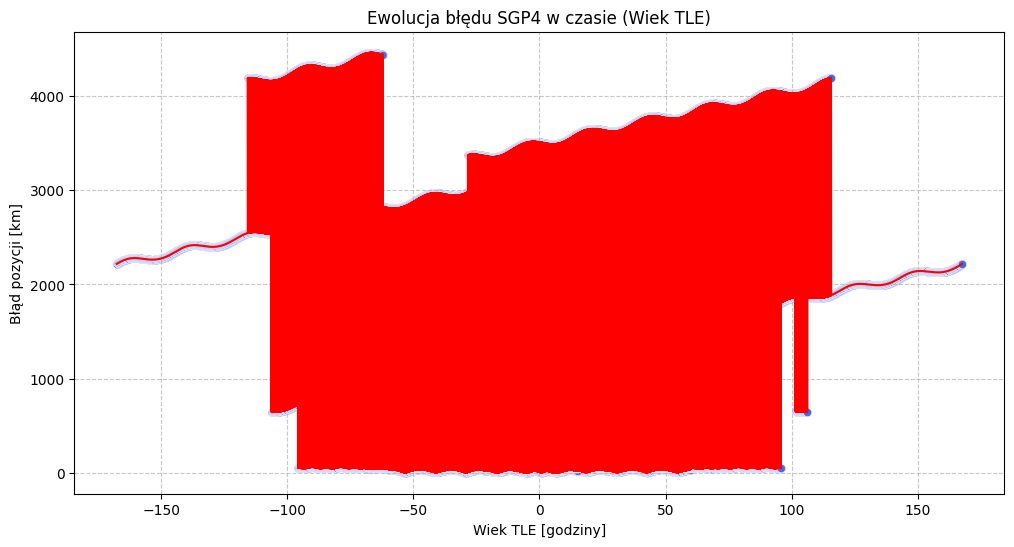

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('OrbitVision_Final_Dataset.csv')


df['total_error_km'] = (df['delta_x']**2 + df['delta_y']**2 + df['delta_z']**2)**0.5

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='age_of_tle_hours', y='total_error_km', alpha=0.6, color='royalblue')
sns.lineplot(data=df, x='age_of_tle_hours', y='total_error_km', color='red', estimator='mean', errorbar=None)

plt.title('Ewolucja błędu SGP4 w czasie (Wiek TLE)')
plt.xlabel('Wiek TLE [godziny]')
plt.ylabel('Błąd pozycji [km]')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()